# A1 Coursework

## Question 1: Likelihood based analysis of the 21-cm power spectrum

### (a) PCA

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lba import (
    TrainingConfig,
    build_emulator,
    cumulative_explained_variance,
    fit_pca_with_observation,
    load_observations,
    load_simulation_dataset,
    normalize_observation,
    normalize_spectra,
    optimize_emulator,
    save_observations_pca,
    save_pca_model,
    save_split_datasets,
    split_training_data,
    test_emulator,
    train_emulator,
    )

# Load the data
data_path = "data"
observations = load_observations(data_path)
simulations = load_simulation_dataset(data_path)

observations_spectrum = observations.power
observations_ks = observations.k
ks = simulations.ks
spectra = simulations.spectra
params = simulations.params
redshift = simulations.redshift
code = simulations.code
code_version = simulations.code_version

/home/alex/projects/a1_coursework/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]
('k', 'power', 'astro_params', 'cosmo_params', 'redshfit', 'code', 'code_version')
Training set size: 7997
Validation set size: 1000
Test set size: 1000
Min power (from training): 6.303388878614356e-07
Max power (from training): 640.3159675853942


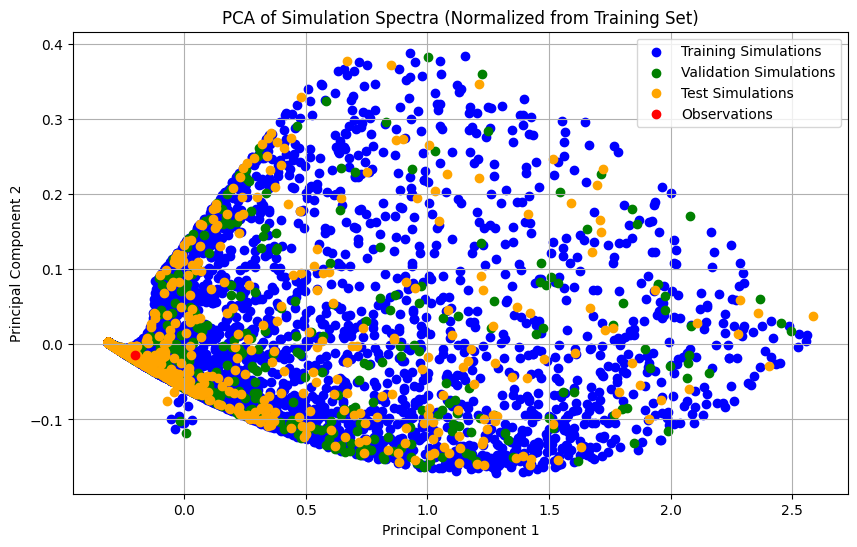

In [4]:
print(observations_ks)
print(("k", "power", "astro_params", "cosmo_params", "redshfit", "code", "code_version"))

# Split the data BEFORE normalization into training, validation, and test sets with 80-10-10 split
splits = split_training_data(
    params,
    spectra,
    train_fraction=0.8,
    val_fraction=0.1,
    test_fraction=0.1,
    random_state=42,
)
spectra_train = splits.y_train
spectra_val = splits.y_val
spectra_test = splits.y_test
params_train = splits.x_train
params_val = splits.x_val
params_test = splits.x_test

print(f"Training set size: {spectra_train.shape[0]}")
print(f"Validation set size: {spectra_val.shape[0]}")
print(f"Test set size: {spectra_test.shape[0]}")

# Compute normalization statistics from training set only
normalized_spectra_train, normalization_stats = normalize_spectra(spectra_train)
# Apply the same normalization to validation and test sets
normalized_spectra_val, _ = normalize_spectra(spectra_val, stats=normalization_stats)
normalized_spectra_test, _ = normalize_spectra(spectra_test, stats=normalization_stats)

# Normalize the observation spectrum using training set statistics
normalized_observations_spectrum = normalize_observation(
    observations_spectrum, normalization_stats
)

max_power = normalization_stats.max_power
min_power = normalization_stats.min_power
print(f"Min power (from training): {min_power}")
print(f"Max power (from training): {max_power}")

# Fit PCA on normalized training spectra (combined with observation for projection space)
pca_results = fit_pca_with_observation(
    normalized_spectra_train,
    normalized_observations_spectrum,
    n_components=2,
)
pca_2 = pca_results.pca_model
pca_2_observations_result = pca_results.observation_components
pca_2_simulations_spectra_train = pca_results.simulation_components

# Transform validation and test sets using the fitted PCA model
pca_2_simulations_spectra_val = pca_2.transform(normalized_spectra_val)
pca_2_simulations_spectra_test = pca_2.transform(normalized_spectra_test)

plt.figure(figsize=(10, 6))
plt.scatter(pca_2_simulations_spectra_train[:, 0], pca_2_simulations_spectra_train[:, 1], c='blue', label='Training Simulations')
plt.scatter(pca_2_simulations_spectra_val[:, 0], pca_2_simulations_spectra_val[:, 1], c='green', label='Validation Simulations')
plt.scatter(pca_2_simulations_spectra_test[:, 0], pca_2_simulations_spectra_test[:, 1], c='orange', label='Test Simulations')
plt.scatter(pca_2_observations_result[:, 0], pca_2_observations_result[:, 1], c='red', label='Observations')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulation Spectra (Normalized from Training Set)')
plt.legend()
plt.grid()
plt.show()


In [5]:
from sklearn.decomposition import PCA

# Fit PCA with 54 components on the training set only
pca_54 = PCA(n_components=54)
pca_54.fit(normalized_spectra_train)
pca_54_result = pca_54.transform(normalized_spectra_train)

print(f"PCA 54 components shape: {pca_54_result.shape}")
print(f"Explained variance ratio: {pca_54.explained_variance_ratio_[:10]}")
print(f"Cumulative explained variance: {cumulative_explained_variance(pca_54)}")


PCA 54 components shape: (7997, 54)
Explained variance ratio: [9.83595420e-01 1.60578516e-02 3.08981448e-04 3.76838811e-05
 5.33825784e-08 9.18437075e-09 1.56757807e-10 9.80806930e-11
 2.67764883e-11 2.37934409e-11]
Cumulative explained variance: [0.98359542 0.99965327 0.99996225 0.99999994 0.99999999 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.        ]


[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


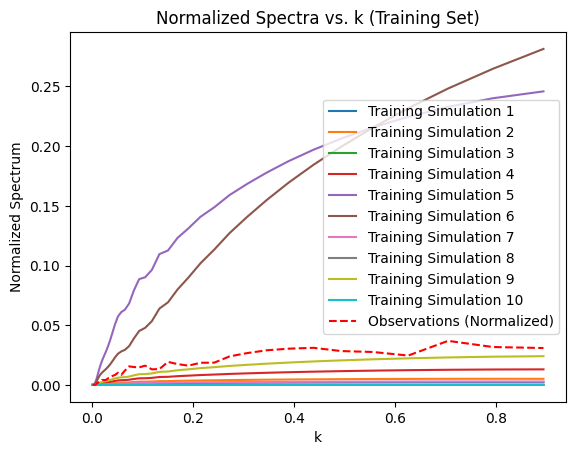

In [6]:
print(ks[0])

# Plot a sample of normalized spectra from the training set
for i in range(min(10, len(normalized_spectra_train))):
    plt.plot(ks[i], normalized_spectra_train[i], label=f"Training Simulation {i+1}")

plt.plot(observations_ks, normalized_observations_spectrum, label="Observations (Normalized)", linestyle='dashed', color='red')

plt.xlabel("k")
plt.ylabel("Normalized Spectrum")
plt.title("Normalized Spectra vs. k (Training Set)")
plt.legend()
plt.show()


We use 2 principal components, which together explain $>99.96\%$ of the variance in the data. We now split the normalised and decomposed simulations into training, validation, and testing samples using an 80:10:10 split. We also apply the same normalisation and PCA reduction to the observed power spectrum.

In [7]:
# Prepare training, validation, and test sets for the neural network
# (using parameters as inputs and PCA-reduced spectra as outputs)
X_train = params_train
X_val = params_val
X_test = params_test
y_train = pca_2_simulations_spectra_train
y_val = pca_2_simulations_spectra_val
y_test = pca_2_simulations_spectra_test

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

# Save preprocessing artifacts
save_split_datasets(
    data_path,
    x_train=X_train,
    y_train=y_train,
    x_val=X_val,
    y_val=y_val,
    x_test=X_test,
    y_test=y_test,
)
save_observations_pca(Path(data_path) / "observations_pca.npz", pca_2_observations_result)
save_pca_model(Path(data_path) / "pca_model.pkl", pca_2)


Training set: X=(7997, 4), y=(7997, 2)
Validation set: X=(1000, 4), y=(1000, 2)
Test set: X=(1000, 4), y=(1000, 2)


### (b)

The data is normalised by subtracting the minimum power in the simulations and dividing by the difference between the maximum power and the minimum power in the simulations.

In [8]:
training_config = TrainingConfig(epochs=200, validation_interval=10)
model = build_emulator(hidden_units=training_config.hidden_units, device=training_config.device)
history = train_emulator(
    model,
    X_train,
    y_train,
    x_val=X_val,
    y_val=y_val,
    config=training_config,
 )

for epoch_number, val_loss in zip(
    range(
        training_config.validation_interval,
        training_config.epochs + 1,
        training_config.validation_interval,
    ),
    history.val_loss,
 ):
    train_loss = history.train_loss[epoch_number - 1]
    print(
        f"Epoch [{epoch_number}/{training_config.epochs}], "
        f"Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}"
    )

evaluation = test_emulator(model, X_test, y_test)
print(f"Test MSE: {evaluation.mse:.4f}")

Epoch [10/200], Loss: 0.1292, Validation Loss: 0.1211
Epoch [20/200], Loss: 0.0976, Validation Loss: 0.0898
Epoch [30/200], Loss: 0.0568, Validation Loss: 0.0500
Epoch [40/200], Loss: 0.0234, Validation Loss: 0.0193
Epoch [50/200], Loss: 0.0132, Validation Loss: 0.0116
Epoch [60/200], Loss: 0.0106, Validation Loss: 0.0100
Epoch [70/200], Loss: 0.0085, Validation Loss: 0.0079
Epoch [80/200], Loss: 0.0068, Validation Loss: 0.0062
Epoch [90/200], Loss: 0.0055, Validation Loss: 0.0050
Epoch [100/200], Loss: 0.0046, Validation Loss: 0.0042
Epoch [110/200], Loss: 0.0038, Validation Loss: 0.0036
Epoch [120/200], Loss: 0.0031, Validation Loss: 0.0030
Epoch [130/200], Loss: 0.0027, Validation Loss: 0.0026
Epoch [140/200], Loss: 0.0022, Validation Loss: 0.0022
Epoch [150/200], Loss: 0.0019, Validation Loss: 0.0019
Epoch [160/200], Loss: 0.0016, Validation Loss: 0.0016
Epoch [170/200], Loss: 0.0014, Validation Loss: 0.0014
Epoch [180/200], Loss: 0.0016, Validation Loss: 0.0013
Epoch [190/200], Lo

[I 2026-03-18 09:42:01,714] A new study created in memory with name: no-name-87777b81-5b82-41e9-b2ec-c8551a24e93f
[I 2026-03-18 09:42:04,476] Trial 0 finished with value: 0.0076397014781832695 and parameters: {'n_hidden_layers': 1, 'n_hidden_units_1': 128, 'dropout_rate_1': 0.42566104414212835, 'optimizer_name': 'rmsprop', 'learning_rate': 0.004553179925132339}. Best is trial 0 with value: 0.0076397014781832695.
[I 2026-03-18 09:42:19,009] Trial 1 finished with value: 0.0016246845480054617 and parameters: {'n_hidden_layers': 4, 'n_hidden_units_1': 32, 'n_hidden_units_2': 128, 'n_hidden_units_3': 256, 'n_hidden_units_4': 16, 'dropout_rate_1': 0.045876534220721354, 'dropout_rate_2': 0.02854781636889764, 'dropout_rate_3': 0.36376922148415924, 'dropout_rate_4': 0.04573001737490384, 'optimizer_name': 'rmsprop', 'learning_rate': 0.001199395127193774}. Best is trial 1 with value: 0.0016246845480054617.
[I 2026-03-18 09:42:30,066] Trial 2 finished with value: 0.009501070715487003 and parameter

Best hyperparameters:  {'n_hidden_layers': 3, 'n_hidden_units_1': 64, 'n_hidden_units_2': 64, 'n_hidden_units_3': 32, 'dropout_rate_1': 0.0197562079576881, 'dropout_rate_2': 0.12878926654931871, 'dropout_rate_3': 0.19160021951770165, 'optimizer_name': 'adam', 'learning_rate': 0.009928721112936275}
Best validation loss:  0.0004259176494088024
Best optimized model saved to: data/best_optimized_model.pt
Optimization curves saved to: data/optimization_curves.png


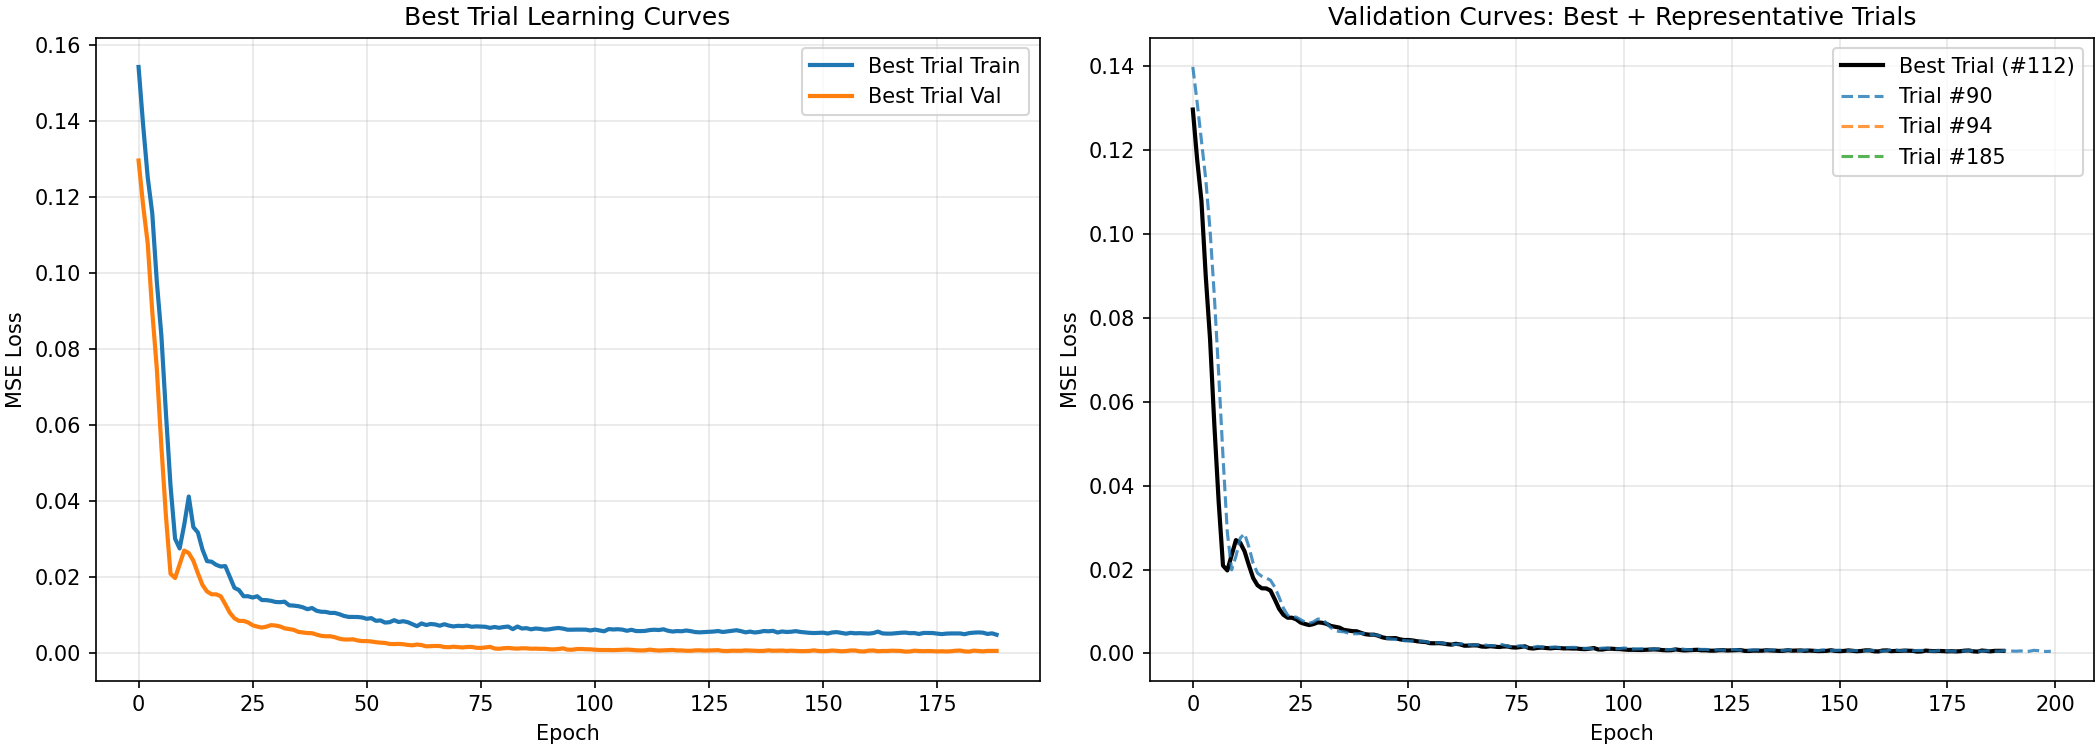

In [9]:
# Optimize the model hyperparameters using Optuna
best_model_path = Path(data_path) / "best_optimized_model.pt"
optimization_curves_path = Path(data_path) / "optimization_curves.png"

optimization_result = optimize_emulator(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    n_trials=200,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    min_epochs_before_stopping=30,
    best_model_path=best_model_path,
    training_curves_plot_path=optimization_curves_path,
    representative_trial_count=3,
 )
study = optimization_result.study
print("Best hyperparameters: ", optimization_result.best_params)
print("Best validation loss: ", optimization_result.best_value)
print("Best optimized model saved to:", optimization_result.best_model_path)
print("Optimization curves saved to:", optimization_result.training_curves_plot_path)

from IPython.display import Image, display
if optimization_result.training_curves_plot_path is not None:
    display(Image(filename=optimization_result.training_curves_plot_path))

In [10]:
# Evaluate the best optimised model on the test set
import torch

best_params = optimization_result.best_params
n_hidden_layers = int(best_params["n_hidden_layers"])
hidden_units = tuple(int(best_params[f"n_hidden_units_{i + 1}"]) for i in range(n_hidden_layers))
dropout_rates = tuple(float(best_params[f"dropout_rate_{i + 1}"]) for i in range(n_hidden_layers))
device = training_config.device

best_model = build_emulator(
    input_dim=X_test.shape[1],
    hidden_units=hidden_units,
    dropout_rates=dropout_rates,
    output_dim=y_test.shape[1],
    device=device,
)
best_model.load_state_dict(torch.load(optimization_result.best_model_path, map_location=device))
best_model.to(device)
best_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)
    predictions = best_model(X_test_tensor)
    mse_loss = torch.nn.MSELoss()(predictions, y_test_tensor)
print(f"Test MSE of best optimized model: {mse_loss.item():.4f}")

Test MSE of best optimized model: 0.0009


### (c)

To do Bayesian analysis we first define priors on the four parameters and a prior on the noise fraction. The noise fraction spans several orders of magnitude, so suggest a log-uniform prior from $10^{-3}$ to $1$.

For parameters that span multiple orders of magnitude, use similar priors. Otherwise, use uniform priors from the lowest to the highest observed values.

In [11]:
# Import MCMC utilities from the package module
import numpy as np

from lba.mcmc import (
    build_parameter_priors,
    log_posterior,
    noise_prior_type,
    sample_initial_positions,
)


def print_prior_summary(prior_specs):
    print("Parameter bounds and selected priors:")
    for spec in prior_specs:
        span_orders = spec["span_orders"]
        span_text = "n/a" if not np.isfinite(span_orders) else f"{span_orders:.2f}"
        print(
            f"  param_{spec['index']}: min={spec['min']:.6g}, max={spec['max']:.6g}, "
            f"span_orders={span_text}, prior={spec['prior']}"
        )

In [12]:
from emcee import EnsembleSampler

# Build adaptive priors from training-parameter ranges.
prior_specs = build_parameter_priors(params_train, order_threshold=2.0)
print_prior_summary(prior_specs)
noise_bounds = (1e-3, 1.0)
print(f"Noise prior bounds: [{noise_bounds[0]:.1e}, {noise_bounds[1]:.1e}] ({noise_prior_type(noise_bounds)})")

# Run MCMC sampling using posterior = prior + emulator-based likelihood.
n_walkers = 50
n_dims = 5  # 4 astrophysical/cosmological parameters + 1 noise fraction
initial_pos = sample_initial_positions(n_walkers, prior_specs, noise_bounds)

sampler = EnsembleSampler(
    n_walkers,
    n_dims,
    log_posterior,
    args=(
        best_model,
        pca_results.pca_model,
        observations_spectrum,
        normalization_stats,
        prior_specs,
        noise_bounds,
    ),
)
sampler.run_mcmc(initial_pos, 40000, progress=True)

Parameter bounds and selected priors:
  param_0: min=0.100003, max=9.99913, span_orders=2.00, prior=uniform
  param_1: min=0.00100144, max=0.999614, span_orders=3.00, prior=log_uniform
  param_2: min=0.00100062, max=0.999796, span_orders=3.00, prior=log_uniform
  param_3: min=0.500054, max=0.99999, span_orders=0.30, prior=uniform
Noise prior bounds: [1.0e-03, 1.0e+00] (log_uniform)


100%|██████████| 40000/40000 [03:49<00:00, 174.64it/s]


State([[7.10403526e-01 7.07166779e-03 6.93329745e-02 8.75042724e-01
  2.67117872e-03]
 [9.88219184e+00 8.92045231e-03 7.03443758e-01 5.91045620e-01
  9.13781665e-01]
 [1.01555003e+00 4.53935015e-02 6.78699359e-02 7.74475204e-01
  3.28552013e-02]
 [1.22038683e+00 1.29261275e-03 6.72788956e-02 6.93347187e-01
  3.12735170e-03]
 [9.21992078e-01 1.80608828e-01 7.16077871e-02 9.00818215e-01
  3.34136603e-03]
 [1.53596968e-01 6.45245676e-02 6.14549404e-02 9.33521553e-01
  1.10636454e-03]
 [9.90209460e+00 5.21872698e-03 7.56788935e-01 6.55586781e-01
  9.77886285e-01]
 [9.35208770e+00 1.50912977e-03 7.00616531e-01 5.26591963e-01
  6.63080905e-01]
 [4.36932165e-01 2.38647638e-03 6.48450604e-02 6.69345058e-01
  2.05593874e-01]
 [7.88256786e-01 4.21806114e-02 6.86805349e-02 8.19717344e-01
  1.17353821e-01]
 [5.28531094e-01 1.75448804e-03 6.58408866e-02 8.45328706e-01
  4.90123242e-03]
 [9.81795819e+00 6.28346882e-03 7.87409817e-01 6.31644491e-01
  8.50379110e-01]
 [1.60067277e-01 4.23810457e-03 5.

In [13]:
# Get chains and compute parameter estimates
samples = sampler.get_chain(discard=8000, thin=10, flat=True)
parameter_estimates = np.mean(samples, axis=0)
print("Parameter estimates from MCMC sampling:")
print(f"Astrophysical/Cosmological parameters: {parameter_estimates[:4]}")
print(f"Noise fraction: {parameter_estimates[4]:.4f}")

Parameter estimates from MCMC sampling:
Astrophysical/Cosmological parameters: [2.70265067 0.10583755 0.21682885 0.73483446]
Noise fraction: 0.2367


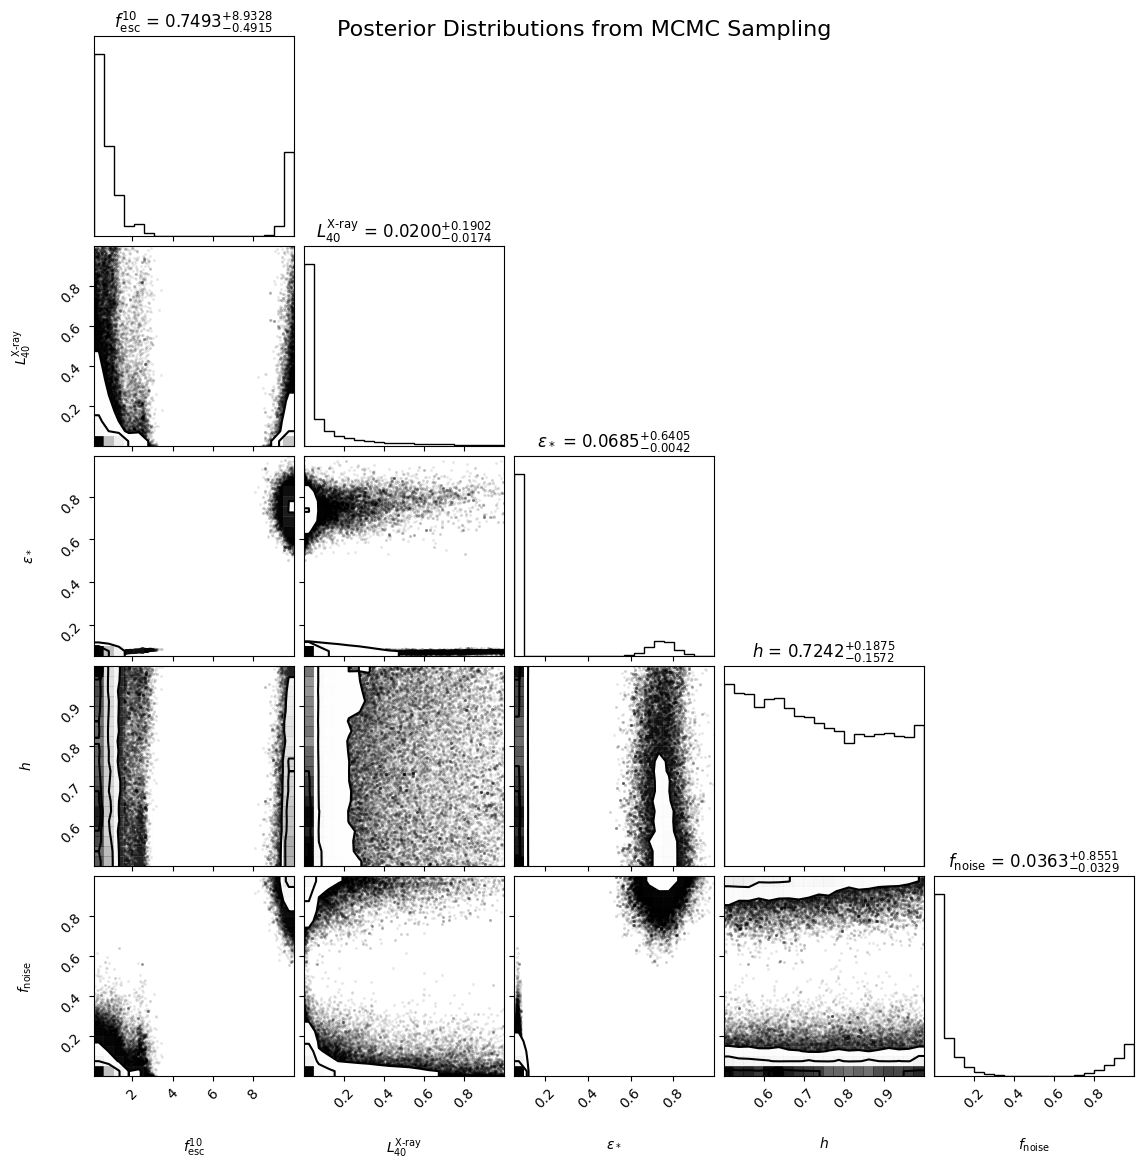

In [17]:
import corner

# Plot corner plot of the posterior samples
labels = ["$f_\\text{esc}^{10}$", "$L_{40}^\\text{X-ray}$", "$\\epsilon_*$", "$h$", "$f_\\text{noise}$"]
fig = corner.corner(
    samples,
    labels=labels,
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
)
plt.suptitle("Posterior Distributions from MCMC Sampling", fontsize=16)
plt.show()

## Question 2: Simulation based inference of the 21-cm power spectrum

### (a) Description of NRE

### (b) Create realistic mocks by drawing noise from likelihood function

Sampled noise fraction: 0.0121
[1.09125049e-06 2.69703213e-06 6.62590779e-06 1.61646464e-05
 3.91161518e-05 9.37609469e-05 2.22273245e-04 5.20198987e-04
 1.19940149e-03 2.71748206e-03 6.03236648e-03 1.30734293e-02
 2.75487899e-02 5.61758833e-02 1.10258678e-01 2.07060726e-01
 3.69796940e-01 6.24422282e-01 9.92594328e-01 1.48291786e+00
 2.08866667e+00 2.79784891e+00 3.61949707e+00 4.60885475e+00
 5.88103399e+00 7.63876473e+00 1.01873787e+01 1.39121487e+01
 1.88807887e+01 2.39246347e+01 2.69699790e+01 2.86214594e+01
 3.31495558e+01 4.38770669e+01 5.41595224e+01 5.50595398e+01
 6.15767606e+01 7.76563945e+01 8.00101273e+01 9.30645776e+01
 1.02566906e+02 1.14961237e+02 1.24714121e+02 1.38670713e+02
 1.51200894e+02 1.64551610e+02 1.78629414e+02 1.92811710e+02
 2.06949671e+02 2.20762492e+02 2.33797450e+02 2.44978728e+02
 2.52859649e+02 2.55907572e+02]


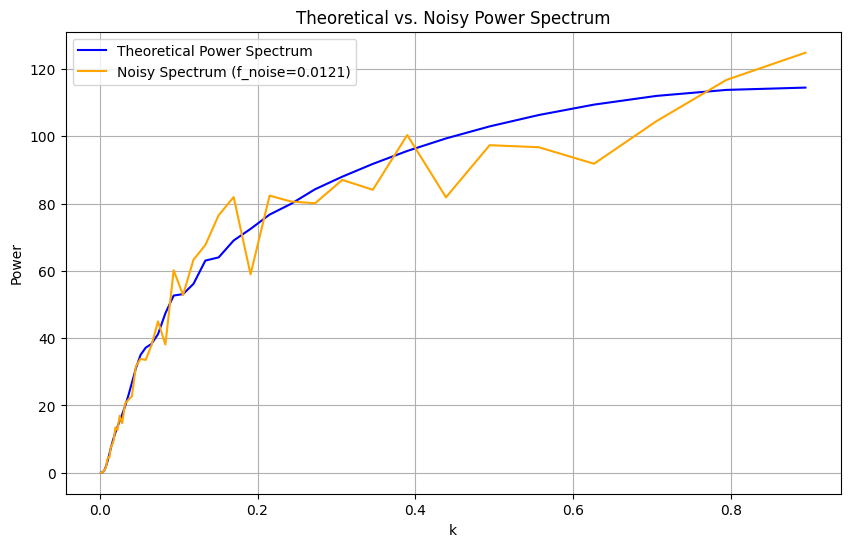

In [32]:
P_model = np.load("data/simulations/simulations/sample_000000.npz")["power"]

# Sample a noise fraction from a log-uniform distribution
f_noise = np.exp(np.random.uniform(np.log(noise_bounds[0]), np.log(noise_bounds[1])))
print(f"Sampled noise fraction: {f_noise:.4f}")

# Compute variance given theoretical power spectrum
variance = 2 * (1 - f_noise) ** 2 * P_model ** 2/ 100

print(variance)

noisy_spectrum = np.random.normal(loc=P_model, scale=np.sqrt(variance))

plt.figure(figsize=(10, 6))
plt.plot(ks[0], P_model, label="Theoretical Power Spectrum", color='blue')
plt.plot(ks[0], noisy_spectrum, label=f"Noisy Spectrum (f_noise={f_noise:.4f})", color='orange')
plt.xlabel("k")
plt.ylabel("Power")
plt.title("Theoretical vs. Noisy Power Spectrum")
plt.legend()
plt.grid()
plt.show()

Mock spectrum generated with noise fraction: 0.3520


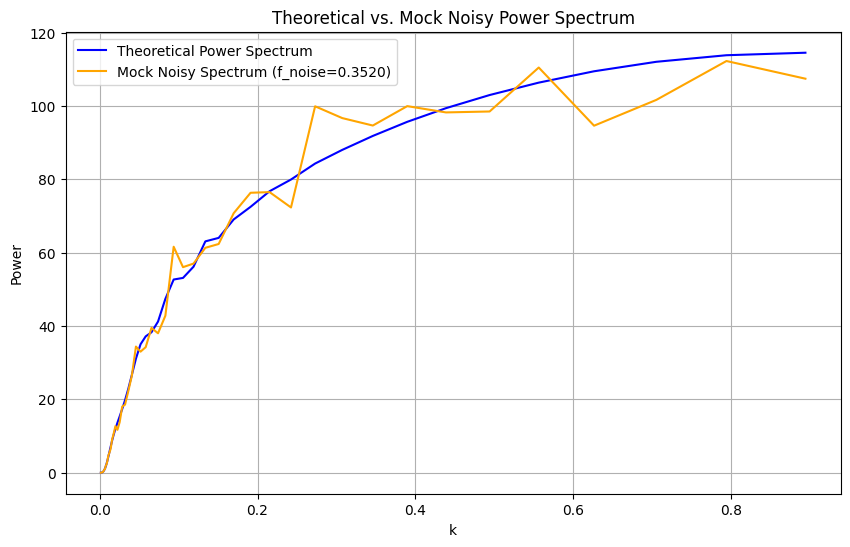

In [39]:
def generate_noisy_spectrum(data_path, sample_number, simulations_data=None):
    if simulations_data is None:
        simulations_data = load_simulation_dataset(data_path)

    if not 0 <= sample_number < len(simulations_data.spectra):
        raise IndexError(
            f"sample_number {sample_number} out of range for {len(simulations_data.spectra)} samples"
        )

    model_spectrum = np.asarray(simulations_data.spectra[sample_number], dtype=float)
    model_params = np.asarray(simulations_data.params[sample_number], dtype=float)

    f_noise = np.exp(np.random.uniform(np.log(noise_bounds[0]), np.log(noise_bounds[1])))
    variance = 2 * (1 - f_noise) ** 2 * model_spectrum ** 2 / 100
    noisy_spectrum = np.random.normal(loc=model_spectrum, scale=np.sqrt(variance))

    return noisy_spectrum, model_params, f_noise, model_spectrum


mock_spectrum, mock_params, mock_f_noise, mock_model_spectrum = generate_noisy_spectrum(
    data_path,
    sample_number=0,
    simulations_data=simulations,
)
print(f"Mock spectrum generated with noise fraction: {mock_f_noise:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(ks[0], mock_model_spectrum, label="Theoretical Power Spectrum", color="blue")
plt.plot(
    ks[0],
    mock_spectrum,
    label=f"Mock Noisy Spectrum (f_noise={mock_f_noise:.4f})",
    color="orange",
)
plt.xlabel("k")
plt.ylabel("Power")
plt.title("Theoretical vs. Mock Noisy Power Spectrum")
plt.legend()
plt.grid()
plt.show()

In [40]:
# Loop through all samples and generate noisy spectra. 
# Save results to data directory with all five parameters.
# To augment data, generate noisy spectra for each sample multiple times with different noise realizations.

for sample_number in range(len(simulations.spectra)):
    for noise_realization in range(5):  # Generate 5 noisy spectra per sample
        noisy_spectrum, model_params, f_noise, model_spectrum = generate_noisy_spectrum(
            data_path,
            sample_number=sample_number,
            simulations_data=simulations,
        )
        # Save the noisy spectrum and associated parameters to a file
        output_path = Path(data_path) / "noisy_spectra" / f"noisy_sample_{sample_number}_realization_{noise_realization}.npz"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez(
            output_path,
            noisy_spectrum=noisy_spectrum,
            model_params=model_params,
            f_noise=f_noise,
            model_spectrum=model_spectrum,
        )

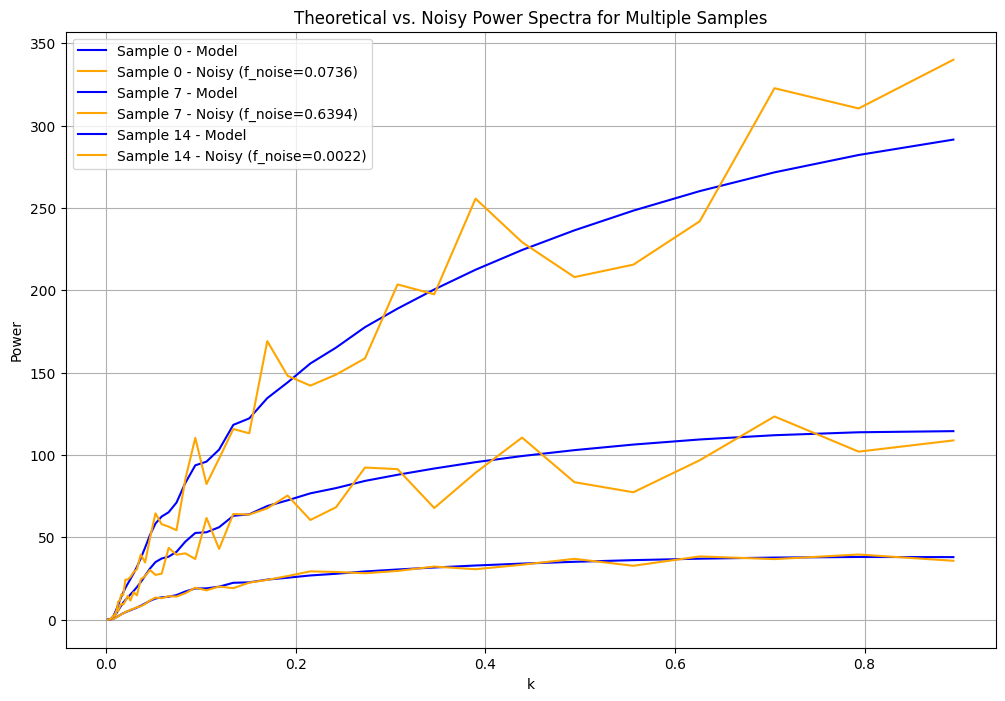

In [53]:
# Plot a few true and noisy spectra from the augmented dataset.
# Label with noise fraction and parameters.

plt.figure(figsize=(12, 8))
for i in range(0, 20, 7):  # Plot 3 samples
    sample_number = i
    noisy_spectrum, model_params, f_noise, model_spectrum = generate_noisy_spectrum(
        data_path,
        sample_number=sample_number,
        simulations_data=simulations,
    )
    plt.plot(ks[0], model_spectrum, label=f"Sample {sample_number} - Model", color="blue")
    plt.plot(
        ks[0],
        noisy_spectrum,
        label=f"Sample {sample_number} - Noisy (f_noise={f_noise:.4f})",
        color="orange",
    )
plt.xlabel("k")
plt.ylabel("Power")
plt.title("Theoretical vs. Noisy Power Spectra for Multiple Samples")
plt.legend()
plt.grid()
plt.show()

In [55]:
# Generate noisy spectra and create spectrum-parameter pairs with labels.
# For each noisy spectrum:
# - Save it with its true parameters and label 1
# - Save it with 3 different sets of shuffled parameters and label 0

num_noisy_per_sample = 5
num_shuffles = 3  # Number of different shuffled parameter sets per noisy spectrum

# Storage for all pairs
spectra_list = []
params_list = []
labels_list = []

np.random.seed(42)  # For reproducibility

for sample_idx in range(len(simulations.spectra)):
    for noise_realization in range(num_noisy_per_sample):
        # Generate a noisy spectrum for this sample
        noisy_spectrum, true_params, f_noise, _ = generate_noisy_spectrum(
            data_path,
            sample_number=sample_idx,
            simulations_data=simulations,
        )
        
        # Save the noisy spectrum with true parameters and label 1
        spectra_list.append(noisy_spectrum)
        params_list.append(true_params)
        labels_list.append(1)
        
        # Generate 3 shuffled parameter sets for this noisy spectrum
        for shuffle_idx in range(num_shuffles):
            # Randomly select a different sample's parameters
            shuffled_sample_idx = np.random.randint(0, len(simulations.spectra))
            # Ensure it's not the original sample
            while shuffled_sample_idx == sample_idx:
                shuffled_sample_idx = np.random.randint(0, len(simulations.spectra))
            
            shuffled_params = np.asarray(simulations.params[shuffled_sample_idx], dtype=float)
            
            # Save the noisy spectrum with shuffled parameters and label 0
            spectra_list.append(noisy_spectrum)
            params_list.append(shuffled_params)
            labels_list.append(0)

# Convert to numpy arrays for saving
spectra_array = np.asarray(spectra_list, dtype=float)
params_array = np.asarray(params_list, dtype=float)
labels_array = np.asarray(labels_list, dtype=int)

# Save all pairs to a file
output_path = Path(data_path) / "noisy_spectrum_parameter_pairs.npz"
np.savez(
    output_path,
    spectra=spectra_array,
    params=params_array,
    labels=labels_array,
)

total_pairs = len(spectra_list)
num_label_1 = np.sum(labels_array == 1)
num_label_0 = np.sum(labels_array == 0)

print(f"Generated {num_noisy_per_sample} noisy spectra per sample × {len(simulations.spectra)} samples")
print(f"Total pairs: {total_pairs}")
print(f"  Label 1 (true pairs): {num_label_1}")
print(f"  Label 0 (shuffled pairs): {num_label_0}")
print(f"Saved to {output_path}")

Generated 5 noisy spectra per sample × 9997 samples
Total pairs: 199940
  Label 1 (true pairs): 49985
  Label 0 (shuffled pairs): 149955
Saved to data/noisy_spectrum_parameter_pairs.npz


### (d) Build and train an NRE

In [63]:
# Split the true and shuffled pairs into training, validation, and test sets
# with an 80-10-10 split, ensuring balanced classes in each set.

train_size = int(0.8 * len(spectra_array))
val_size = int(0.1 * len(spectra_array))
test_size = len(spectra_array) - train_size - val_size

# Create indices for each class
label_1_indices = np.where(labels_array == 1)[0]
label_0_indices = np.where(labels_array == 0)[0]

# Shuffle indices
np.random.shuffle(label_1_indices)
np.random.shuffle(label_0_indices)

# Split indices for each class
label_1_train_idx = label_1_indices[:int(0.8 * len(label_1_indices))]
label_1_val_idx = label_1_indices[int(0.8 * len(label_1_indices)):int(0.9 * len(label_1_indices))]
label_1_test_idx = label_1_indices[int(0.9 * len(label_1_indices)):]
label_0_train_idx = label_0_indices[:int(0.8 * len(label_0_indices))]
label_0_val_idx = label_0_indices[int(0.8 * len(label_0_indices)):int(0.9 * len(label_0_indices))]
label_0_test_idx = label_0_indices[int(0.9 * len(label_0_indices)):]

# Combine indices for training, validation, and test sets
train_indices = np.concatenate([label_1_train_idx, label_0_train_idx])
val_indices = np.concatenate([label_1_val_idx, label_0_val_idx])
test_indices = np.concatenate([label_1_test_idx, label_0_test_idx])

# Shuffle the combined indices
np.random.shuffle(train_indices)
np.random.shuffle(val_indices)
np.random.shuffle(test_indices)

# Create split arrays for spectra, params, labels
X_train_spectrum = spectra_array[train_indices]
X_val_spectrum = spectra_array[val_indices]
X_test_spectrum = spectra_array[test_indices]

X_train_params = params_array[train_indices]
X_val_params = params_array[val_indices]
X_test_params = params_array[test_indices]

y_train = labels_array[train_indices]
y_val = labels_array[val_indices]
y_test = labels_array[test_indices]

print(f"Training set: spectrum={X_train_spectrum.shape}, params={X_train_params.shape}, y={y_train.shape}")
print(f"Validation set: spectrum={X_val_spectrum.shape}, params={X_val_params.shape}, y={y_val.shape}")
print(f"Test set: spectrum={X_test_spectrum.shape}, params={X_test_params.shape}, y={y_test.shape}")

# Determine normalization statistics from the training set only
spec_min = np.min(X_train_spectrum)
spec_max = np.max(X_train_spectrum)
spec_den = max(spec_max - spec_min, 1e-12)

param_min = np.min(X_train_params, axis=0)
param_max = np.max(X_train_params, axis=0)
param_den = np.maximum(param_max - param_min, 1e-12)

print(f"Training spectrum range: min={spec_min:.6g}, max={spec_max:.6g}")

# Normalize spectrum and parameter features using training-only stats
X_train_spectrum_norm = (X_train_spectrum - spec_min) / spec_den
X_val_spectrum_norm = (X_val_spectrum - spec_min) / spec_den
X_test_spectrum_norm = (X_test_spectrum - spec_min) / spec_den

X_train_params_norm = (X_train_params - param_min) / param_den
X_val_params_norm = (X_val_params - param_min) / param_den
X_test_params_norm = (X_test_params - param_min) / param_den

# Build final NRE inputs: [normalized_spectrum, normalized_parameters]
X_train_normalized = np.concatenate([X_train_spectrum_norm, X_train_params_norm], axis=1)
X_val_normalized = np.concatenate([X_val_spectrum_norm, X_val_params_norm], axis=1)
X_test_normalized = np.concatenate([X_test_spectrum_norm, X_test_params_norm], axis=1)

print(f"NRE feature dim: {X_train_normalized.shape[1]} = {X_train_spectrum_norm.shape[1]} spectrum + {X_train_params_norm.shape[1]} params")

# Save the normalized splits to files
np.savez(
    Path(data_path) / "noisy_spectrum_parameter_pairs_train.npz",
    X=X_train_normalized,
    y=y_train,
    X_spectrum=X_train_spectrum_norm,
    X_params=X_train_params_norm,
)
np.savez(
    Path(data_path) / "noisy_spectrum_parameter_pairs_val.npz",
    X=X_val_normalized,
    y=y_val,
    X_spectrum=X_val_spectrum_norm,
    X_params=X_val_params_norm,
)
np.savez(
    Path(data_path) / "noisy_spectrum_parameter_pairs_test.npz",
    X=X_test_normalized,
    y=y_test,
    X_spectrum=X_test_spectrum_norm,
    X_params=X_test_params_norm,
)

Training set: spectrum=(159952, 54), params=(159952, 4), y=(159952,)
Validation set: spectrum=(19993, 54), params=(19993, 4), y=(19993,)
Test set: spectrum=(19995, 54), params=(19995, 4), y=(19995,)
Training spectrum range: min=4.11576e-07, max=891.155
NRE feature dim: 58 = 54 spectrum + 4 params


In [64]:
# Build the NRE.
# The NRE takes concatenated [spectrum, parameter] features as input and outputs
# a probability of being a true pair (label 1) vs. a shuffled pair (label 0).

import torch


class NeuralRatioEstimator(torch.nn.Module):
    def __init__(self, input_dim, hidden_units, dropout_rates):
        super(NeuralRatioEstimator, self).__init__()
        layers = []
        for i in range(len(hidden_units)):
            layers.append(torch.nn.Linear(input_dim if i == 0 else hidden_units[i - 1], hidden_units[i]))
            layers.append(torch.nn.ReLU())
            if dropout_rates[i] > 0:
                layers.append(torch.nn.Dropout(dropout_rates[i]))
        layers.append(torch.nn.Linear(hidden_units[-1], 1))
        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(-1)


# Example instantiation of the NRE
input_dim = X_train_normalized.shape[1]
hidden_units = [192, 96]
dropout_rates = [0.2, 0.1]
nre_model = NeuralRatioEstimator(input_dim, hidden_units, dropout_rates)
print(nre_model)

NeuralRatioEstimator(
  (network): Sequential(
    (0): Linear(in_features=58, out_features=192, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=192, out_features=96, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=96, out_features=1, bias=True)
  )
)


In [65]:
# Train the NRE using the normalized training set and evaluate on the validation set.
# Use early stopping based on validation loss to prevent overfitting.

def train_nre(model, X_train, y_train, x_val, y_val, epochs, batch_size, learning_rate, early_stopping_patience, early_stopping_min_delta):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        permutation = np.random.permutation(X_train.shape[0])
        for i in range(0, X_train.shape[0], batch_size):
            indices = permutation[i:i + batch_size]
            batch_X = torch.tensor(X_train[indices], dtype=torch.float32).to(device)
            batch_y = torch.tensor(y_train[indices], dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        # Validate the model
        model.eval()
        with torch.no_grad():
            val_X_tensor = torch.tensor(x_val, dtype=torch.float32).to(device)
            val_y_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
            val_outputs = model(val_X_tensor)
            val_loss = criterion(val_outputs, val_y_tensor).item()

        print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {val_loss:.4f}")

        # Early stopping check
        if val_loss < best_val_loss - early_stopping_min_delta:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    return model

nre_21cm = train_nre(
    nre_model,
    X_train_normalized,
    y_train,
    x_val=X_val_normalized,
    y_val=y_val,
    epochs=100,
    batch_size=64,
    learning_rate=1e-3,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
)

Epoch 1/100, Validation Loss: 0.2635
Epoch 2/100, Validation Loss: 0.2155
Epoch 3/100, Validation Loss: 0.1976
Epoch 4/100, Validation Loss: 0.1803
Epoch 5/100, Validation Loss: 0.1656
Epoch 6/100, Validation Loss: 0.1501
Epoch 7/100, Validation Loss: 0.1494
Epoch 8/100, Validation Loss: 0.1412
Epoch 9/100, Validation Loss: 0.1284
Epoch 10/100, Validation Loss: 0.1284
Epoch 11/100, Validation Loss: 0.1261
Epoch 12/100, Validation Loss: 0.1225
Epoch 13/100, Validation Loss: 0.1358
Epoch 14/100, Validation Loss: 0.1157
Epoch 15/100, Validation Loss: 0.1166
Epoch 16/100, Validation Loss: 0.1056
Epoch 17/100, Validation Loss: 0.1080
Epoch 18/100, Validation Loss: 0.0991
Epoch 19/100, Validation Loss: 0.0980
Epoch 20/100, Validation Loss: 0.1097
Epoch 21/100, Validation Loss: 0.0985
Epoch 22/100, Validation Loss: 0.1007
Epoch 23/100, Validation Loss: 0.1002
Epoch 24/100, Validation Loss: 0.0915
Epoch 25/100, Validation Loss: 0.0919
Epoch 26/100, Validation Loss: 0.0934
Epoch 27/100, Validat

In [66]:
# Faster Optuna optimization for the NRE (pair-conditioned input)
import copy
import optuna
from optuna.pruners import MedianPruner

best_nre_model_path = Path(data_path) / "best_nre_model.pt"

# Use smaller subsets for faster hyperparameter search
rng = np.random.default_rng(42)
train_opt_size = min(30000, X_train_normalized.shape[0])
val_opt_size = min(15000, X_val_normalized.shape[0])

train_opt_idx = rng.choice(X_train_normalized.shape[0], size=train_opt_size, replace=False)
val_opt_idx = rng.choice(X_val_normalized.shape[0], size=val_opt_size, replace=False)

X_train_opt = X_train_normalized[train_opt_idx]
y_train_opt = y_train[train_opt_idx]
X_val_opt = X_val_normalized[val_opt_idx]
y_val_opt = y_val[val_opt_idx]


def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    n_hidden_layers = trial.suggest_int("n_hidden_layers", 1, 3)
    hidden_units = tuple(
        trial.suggest_int(f"n_hidden_units_{i + 1}", 32, 192) for i in range(n_hidden_layers)
    )
    dropout_rates = tuple(
        trial.suggest_float(f"dropout_rate_{i + 1}", 0.0, 0.4) for i in range(n_hidden_layers)
    )
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    model = NeuralRatioEstimator(input_dim, hidden_units, dropout_rates).to(device)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience_counter = 0
    early_stopping_patience = 5
    early_stopping_min_delta = 5e-5
    max_epochs = 35

    for epoch in range(max_epochs):
        model.train()
        permutation = np.random.permutation(X_train_opt.shape[0])
        for start in range(0, X_train_opt.shape[0], batch_size):
            indices = permutation[start:start + batch_size]
            batch_X = torch.tensor(X_train_opt[indices], dtype=torch.float32, device=device)
            batch_y = torch.tensor(y_train_opt[indices], dtype=torch.float32, device=device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_X_tensor = torch.tensor(X_val_opt, dtype=torch.float32, device=device)
            val_y_tensor = torch.tensor(y_val_opt, dtype=torch.float32, device=device)
            val_outputs = model(val_X_tensor)
            val_loss = criterion(val_outputs, val_y_tensor).item()

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss - early_stopping_min_delta:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            break

    return best_val_loss


sampler = optuna.samplers.TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=4, n_warmup_steps=6)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

# Faster search budget than before
study.optimize(objective, n_trials=12, timeout=900, show_progress_bar=True)

best_nre_params = study.best_params
print(f"Best NRE hyperparameters: {best_nre_params}")
print(f"Best validation loss (Optuna subset): {study.best_value:.6f}")

# Train final model on full training data with best hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_hidden_layers_best = int(best_nre_params["n_hidden_layers"])
hidden_units_best = tuple(
    int(best_nre_params[f"n_hidden_units_{i + 1}"]) for i in range(n_hidden_layers_best)
)
dropout_rates_best = tuple(
    float(best_nre_params[f"dropout_rate_{i + 1}"]) for i in range(n_hidden_layers_best)
)

best_nre_model = NeuralRatioEstimator(input_dim, hidden_units_best, dropout_rates_best).to(device)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(
    best_nre_model.parameters(),
    lr=float(best_nre_params["learning_rate"]),
    weight_decay=float(best_nre_params["weight_decay"]),
)

batch_size_best = int(best_nre_params["batch_size"])
best_state = copy.deepcopy(best_nre_model.state_dict())
best_val_loss = float("inf")
patience_counter = 0
max_epochs = 60
early_stopping_patience = 8
early_stopping_min_delta = 5e-5

for epoch in range(max_epochs):
    best_nre_model.train()
    permutation = np.random.permutation(X_train_normalized.shape[0])
    for start in range(0, X_train_normalized.shape[0], batch_size_best):
        indices = permutation[start:start + batch_size_best]
        batch_X = torch.tensor(X_train_normalized[indices], dtype=torch.float32, device=device)
        batch_y = torch.tensor(y_train[indices], dtype=torch.float32, device=device)

        optimizer.zero_grad()
        outputs = best_nre_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    best_nre_model.eval()
    with torch.no_grad():
        val_X_tensor = torch.tensor(X_val_normalized, dtype=torch.float32, device=device)
        val_y_tensor = torch.tensor(y_val, dtype=torch.float32, device=device)
        val_outputs = best_nre_model(val_X_tensor)
        val_loss = criterion(val_outputs, val_y_tensor).item()

    print(f"Final train epoch {epoch + 1}/{max_epochs}, val loss: {val_loss:.6f}")

    if val_loss < best_val_loss - early_stopping_min_delta:
        best_val_loss = val_loss
        best_state = copy.deepcopy(best_nre_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print("Final training early stopping triggered.")
        break

best_nre_model.load_state_dict(best_state)
torch.save(best_nre_model.state_dict(), best_nre_model_path)
print(f"Best NRE model saved to {best_nre_model_path}")

# Evaluate on full test set
best_nre_model.eval()
with torch.no_grad():
    test_X_tensor = torch.tensor(X_test_normalized, dtype=torch.float32, device=device)
    test_y_tensor = torch.tensor(y_test, dtype=torch.float32, device=device)
    test_outputs = best_nre_model(test_X_tensor)
    test_loss = criterion(test_outputs, test_y_tensor).item()
    test_pred = (test_outputs >= 0.5).float()
    test_acc = (test_pred == test_y_tensor).float().mean().item()

print(f"Test BCE loss of best NRE model: {test_loss:.6f}")
print(f"Test accuracy of best NRE model: {test_acc:.6f}")

[I 2026-03-18 12:56:51,177] A new study created in memory with name: no-name-91e13325-e064-42ed-9c65-b850f9dcbd02
Best trial: 0. Best value: 0.216468:   8%|▊         | 1/12 [00:30<05:32, 30.26s/it, 30.26/900 seconds]

[I 2026-03-18 12:57:21,440] Trial 0 finished with value: 0.21646766364574432 and parameters: {'n_hidden_layers': 2, 'n_hidden_units_1': 185, 'n_hidden_units_2': 149, 'dropout_rate_1': 0.23946339367881464, 'dropout_rate_2': 0.06240745617697461, 'learning_rate': 0.00018408992080552527, 'weight_decay': 1.7073967431528095e-07, 'batch_size': 64}. Best is trial 0 with value: 0.21646766364574432.


Best trial: 0. Best value: 0.216468:  17%|█▋        | 2/12 [00:36<02:42, 16.26s/it, 36.71/900 seconds]

[I 2026-03-18 12:57:27,893] Trial 1 finished with value: 0.42008161544799805 and parameters: {'n_hidden_layers': 1, 'n_hidden_units_1': 188, 'dropout_rate_1': 0.3329770563201687, 'learning_rate': 0.00022948683681130568, 'weight_decay': 5.337032762603952e-07, 'batch_size': 256}. Best is trial 0 with value: 0.21646766364574432.


Best trial: 2. Best value: 0.172812:  25%|██▌       | 3/12 [01:04<03:11, 21.29s/it, 64.00/900 seconds]

...

[I 2026-03-18 12:59:16,183] Trial 9 pruned. 


Best trial: 4. Best value: 0.111855:  92%|█████████▏| 11/12 [02:30<00:08,  8.31s/it, 150.42/900 seconds]

[I 2026-03-18 12:59:21,594] Trial 10 pruned. 


Best trial: 4. Best value: 0.111855: 100%|██████████| 12/12 [02:38<00:00, 13.23s/it, 158.81/900 seconds]


[I 2026-03-18 12:59:29,984] Trial 11 finished with value: 0.1395600140094757 and parameters: {'n_hidden_layers': 3, 'n_hidden_units_1': 144, 'n_hidden_units_2': 78, 'n_hidden_units_3': 34, 'dropout_rate_1': 0.1380192142897154, 'dropout_rate_2': 0.1589063884410112, 'dropout_rate_3': 0.3827698630983872, 'learning_rate': 0.001601247019540283, 'weight_decay': 2.81140588552311e-06, 'batch_size': 256}. Best is trial 4 with value: 0.1118551641702652.
Best NRE hyperparameters: {'n_hidden_layers': 3, 'n_hidden_units_1': 102, 'n_hidden_units_2': 51, 'n_hidden_units_3': 111, 'dropout_rate_1': 0.013755408446087358, 'dropout_rate_2': 0.3637281608315128, 'dropout_rate_3': 0.10351199264000677, 'learning_rate': 0.0013353819088790589, 'weight_decay': 1.7654048052495067e-06, 'batch_size': 128}
Best validation loss (Optuna subset): 0.111855
Final train epoch 1/60, val loss: 0.258927
Final train epoch 2/60, val loss: 0.201745
Final train epoch 3/60, val loss: 0.179425
Final train epoch 4/60, val loss: 0.1

In [67]:
# NRE diagnostics after pair-conditioned feature fix
import numpy as np
from collections import defaultdict

pos_rate = float(np.mean(y_train))
print(f"Train positive rate: {pos_rate:.6f}")

const_p = np.clip(pos_rate, 1e-8, 1 - 1e-8)
bce_const = -(pos_rate * np.log(const_p) + (1 - pos_rate) * np.log(1 - const_p))
print(f"Best-constant BCE (class-prior baseline): {bce_const:.6f}")

# Check conflicting labels for identical full features [spectrum, params]
Xr = np.round(X_train_normalized, 10)
keys = [row.tobytes() for row in Xr]
label_sets = defaultdict(set)
counts = defaultdict(int)
for k, lbl in zip(keys, y_train):
    label_sets[k].add(int(lbl))
    counts[k] += 1

n_unique = len(label_sets)
n_conflicting = sum(1 for k in label_sets if len(label_sets[k]) > 1)
avg_mult = float(np.mean(list(counts.values())))

print(f"Unique pair-features in train: {n_unique}")
print(f"Unique pair-features with conflicting labels: {n_conflicting}")
print(f"Average repeats per unique pair-feature: {avg_mult:.3f}")

if n_conflicting == 0:
    print("No label conflicts for identical pair inputs: task is now learnable.")
else:
    print("Conflicts still present for identical pair inputs: check data construction.")

Train positive rate: 0.250000
Best-constant BCE (class-prior baseline): 0.562335
Unique pair-features in train: 159944
Unique pair-features with conflicting labels: 0
Average repeats per unique pair-feature: 1.000
No label conflicts for identical pair inputs: task is now learnable.


In [68]:
# Quick summary of optimized NRE run
print("Best params:", best_nre_params)
print(f"Best Optuna subset val loss: {study.best_value:.6f}")
print(f"Final test BCE: {test_loss:.6f}")
print(f"Final test accuracy: {test_acc:.6f}")
print(f"Saved model: {best_nre_model_path}")

Best params: {'n_hidden_layers': 3, 'n_hidden_units_1': 102, 'n_hidden_units_2': 51, 'n_hidden_units_3': 111, 'dropout_rate_1': 0.013755408446087358, 'dropout_rate_2': 0.3637281608315128, 'dropout_rate_3': 0.10351199264000677, 'learning_rate': 0.0013353819088790589, 'weight_decay': 1.7654048052495067e-06, 'batch_size': 128}
Best Optuna subset val loss: 0.111855
Final test BCE: 0.076309
Final test accuracy: 0.973643
Saved model: data/best_nre_model.pt
